In [42]:
#Importing libraries
import os
import librosa
import librosa.display
import librosa.feature
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import random
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

#from torch.backends._coreml import preprocess

Step 1: Data Study

In [2]:
dataset_path = r"speech_commands_v0.02"

In [7]:
classes_lst = ['backward','bed','bird','cat','dog',
           'eight','follow','forward','wow','yes',]

In [8]:
dtset_info = []
tot_files = 0
tot_duration = 0
sample_rates = []
for cls in classes_lst:
    folder = os.path.join(dataset_path, cls)
    wav_files = [f for f in os.listdir(folder)
                 if f.endswith(".wav")]
    count = len(wav_files)
    tot_files += count
    duration = 0
    sr = None
    for file in wav_files:
        path = os.path.join(folder, file)
        y, sr = librosa.load(path, sr=None)
        duration += len(y)/sr
        sample_rates.append(sr)
    tot_duration += duration
    dtset_info.append({
        "Class": cls,
        "Samples": count,
        "Duration (sec)": round(duration,2),
        "Sample Rate": sr
    })

D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
df_summary = pd.DataFrame(dtset_info)
df_summary.head()

,Class,Samples,Duration (sec),Sample Rate
0,backward,1664,1641.35,16000
1,bed,2014,1954.58,16000
2,bird,2064,2000.95,16000
3,cat,2031,1974.26,16000
4,dog,2128,2068.90,16000


In [10]:
# Samples statistic
print("Number of Classes :", len(classes_lst))
print("Total Samples :", tot_files)
print("Total Duration (minutes):",round(tot_duration/60,2))
print("Unique Sample Rates:",sorted(set(sample_rates)))

Number of Classes : 10
Total Samples : 22991
Total Duration (minutes): 374.58
Unique Sample Rates: [16000]


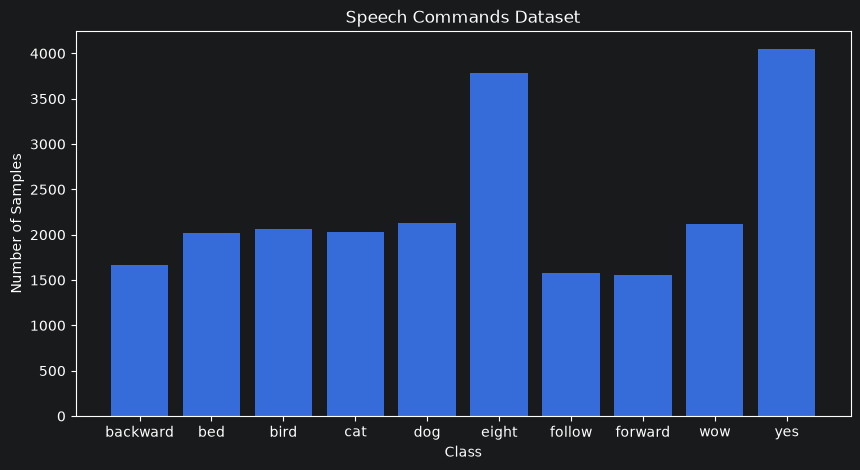

In [11]:
# Plotting Class distribution
plt.figure(figsize=(10,5))
plt.bar(df_summary["Class"],df_summary["Samples"])
plt.title("Speech Commands Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

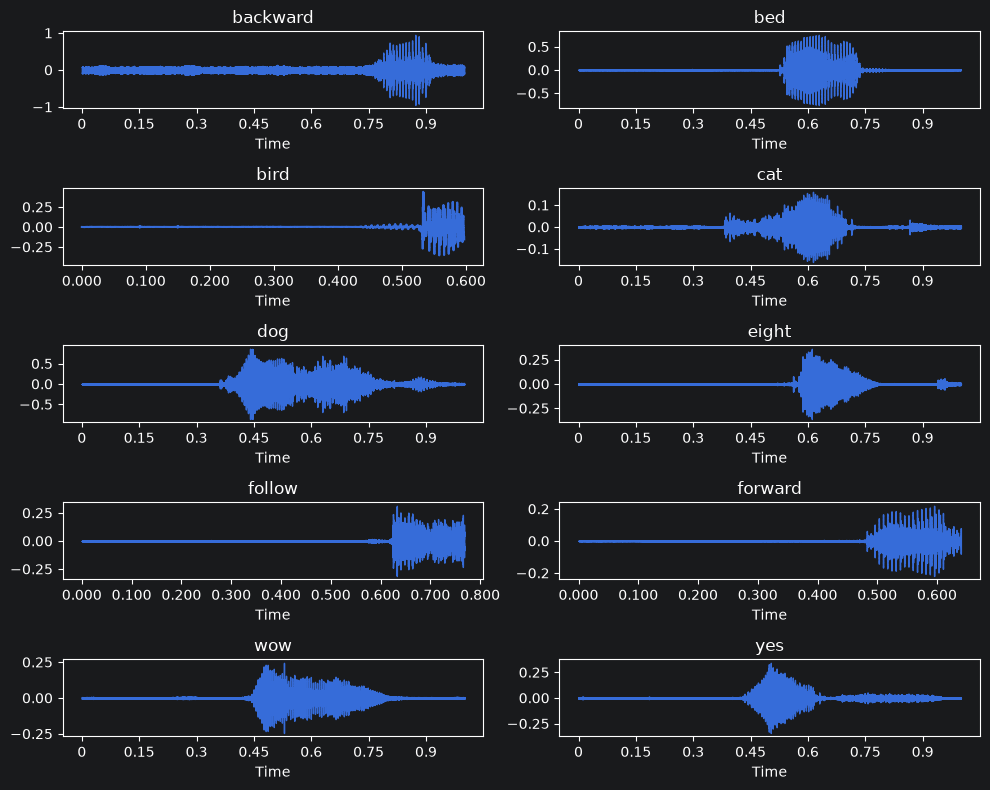

In [17]:
plt.figure(figsize=(10,8))
for i, cls in enumerate(classes_lst):
    folder = os.path.join(dataset_path, cls)
    file = os.listdir(folder)[0]
    path = os.path.join(folder, file)
    y, sr = librosa.load(path, sr=None)
    plt.subplot(5,2,(i+1))
    librosa.display.waveshow(y,sr=sr)
    plt.title(cls)

plt.tight_layout()
plt.show()

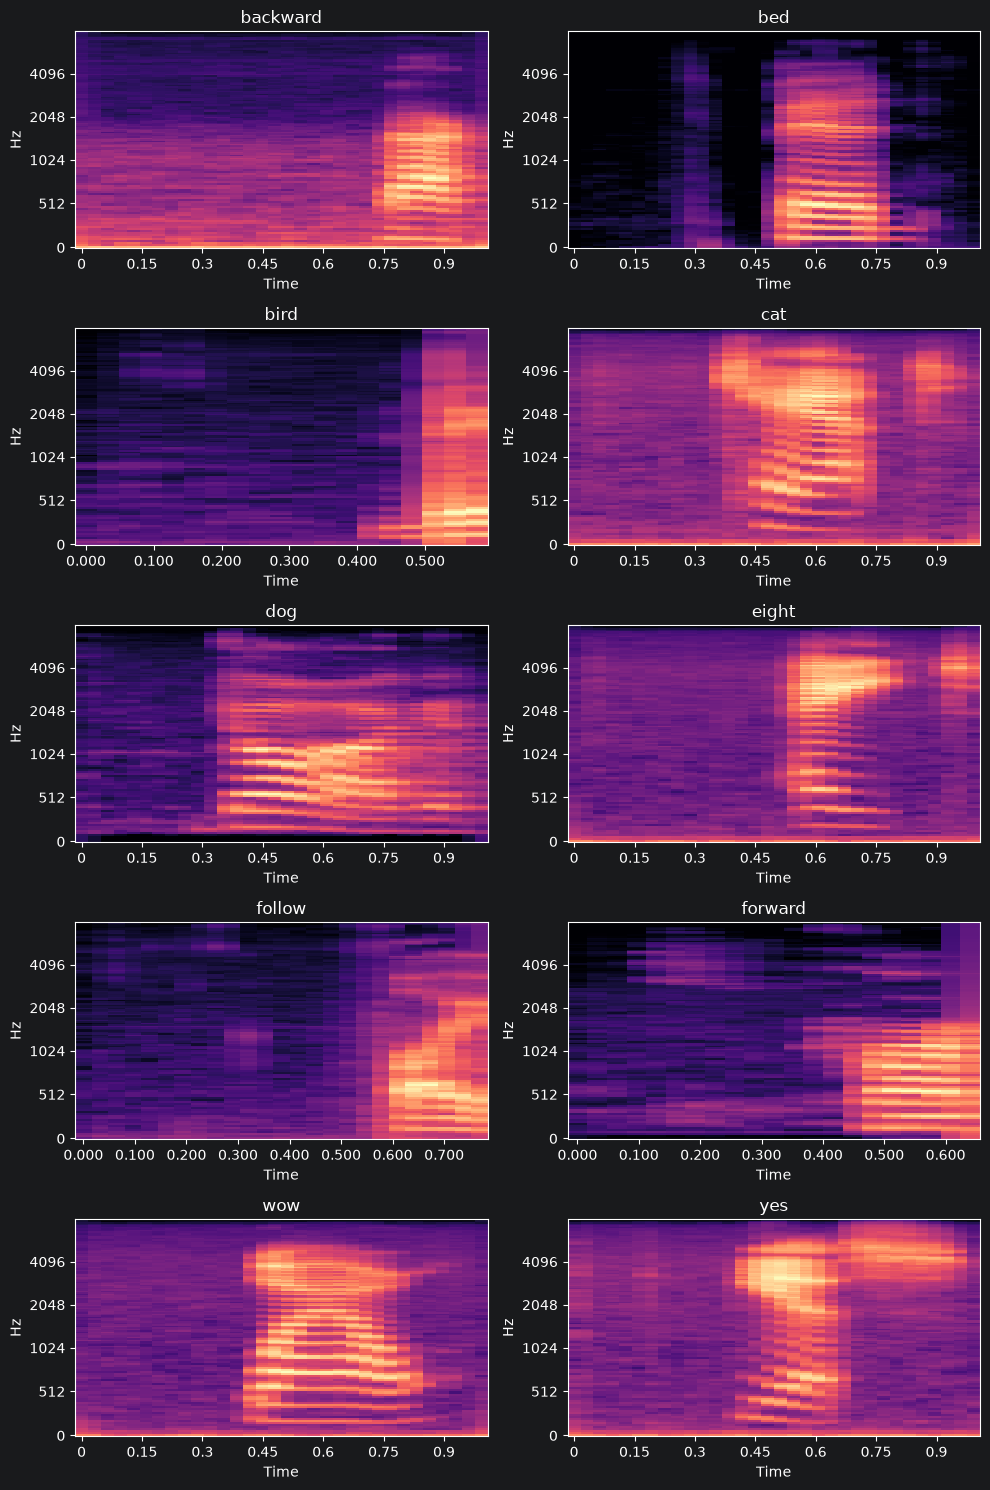

In [22]:
#plotting spectrogram
plt.figure(figsize=(10,15))
for i, cls in enumerate(classes_lst):
    folder = os.path.join(dataset_path, cls)
    file = os.listdir(folder)[0]
    path = os.path.join(folder, file)
    y, sr = librosa.load(path, sr=None)
    plt.subplot(5,2,(i+1))
    mel_spect = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_spect_db = librosa.power_to_db(mel_spect,ref=np.max)
    librosa.display.specshow(mel_spect_db,sr=sr,x_axis='time',y_axis='mel')
    plt.title(cls)

plt.tight_layout()
plt.show()

Step 2: Audio Preprocessing


In [30]:
class AudioPreprocessor:
    def __init__(self, sr=16000, n_mels=64, n_fft=1024, hop_length=512, target_duration=4.0):
        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_samples = int(sr * target_duration)

    def load_and_resample(self, path):
        """Load audio file, convert to mono, resample to self.sr."""
        y, original_sr = librosa.load(path,sr=None,mono=True)
        if original_sr != self.sr:
            y = librosa.resample(y,orig_sr=original_sr,target_sr=self.sr)
        return y

    def pad_or_truncate(self, y):
        """Fix length to target_samples. Pad short clips with zeros, truncate long clips."""
        #padding
        if len(y) < self.target_samples:
            padding = self.target_samples - len(y)
            y = np.pad(y,(0, padding), mode="constant")
        else:
            #truncating
            y = y[:self.target_samples]
        return y

    def extract_mel_spectrogram(self, y):
        """
        Compute log mel spectrogram.
        Return shape: (1, n_mels, num_frames) ready for CNN input.
        """
        mel = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels)
        log_mel = librosa.power_to_db(mel,ref=np.max)
        #passing reshaped log_mel
        return log_mel[np.newaxis, :, :]

    def process(self, path):
        """Full pipeline: load -> resample -> pad/truncate -> mel spectrogram."""
        y = self.load_and_resample(path)
        y = self.pad_or_truncate(y)
        mel = self.extract_mel_spectrogram(y)
        return mel


The target_duration is set to 1.0 sec from 4.0 sec as most of the sample contains less duration. This can avoid memory loss

In [24]:
preprocessor = AudioPreprocessor()

In [36]:
# Getting a sample data from dataset and resampling it
sample_path = os.path.join(
    dataset_path,"yes",os.listdir(os.path.join(dataset_path, "yes"))[0]
)
print(sample_path)

speech_commands_v0.02\yes\004ae714_nohash_0.wav


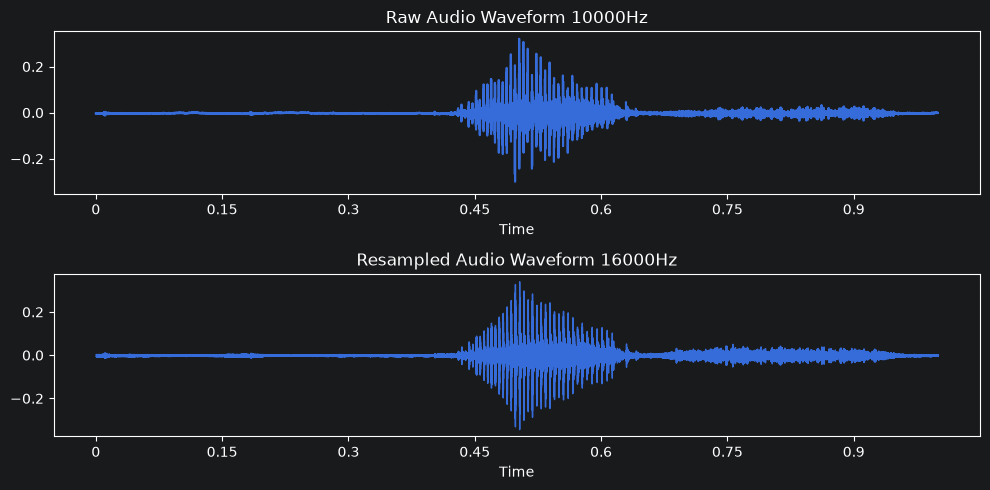

In [34]:
raw_audio, raw_sr = librosa.load(sample_path, sr=10000)
resample_audio = preprocessor.load_and_resample(sample_path)

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
librosa.display.waveshow(raw_audio,sr=raw_sr)
plt.title(f"Raw Audio Waveform {raw_sr}Hz")
plt.subplot(2,1,2)
librosa.display.waveshow(resample_audio,sr=preprocessor.sr)
plt.title(f"Resampled Audio Waveform {preprocessor.sr}Hz")

plt.tight_layout()
plt.show()

If both the raw and resampled is of same the output will look same. Hence the raw data is loaded with a different sample rate

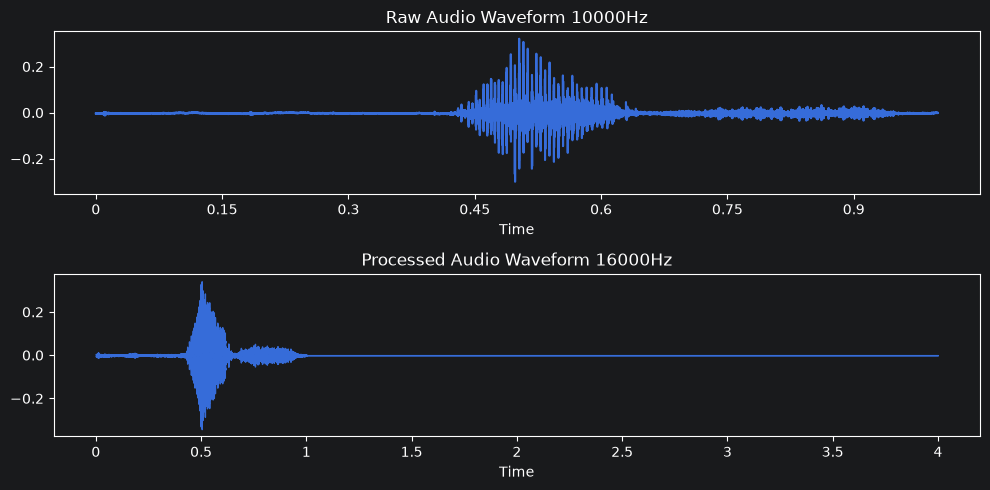

In [37]:
# Padding and truncation
processed_audio = preprocessor.pad_or_truncate(resample_audio)

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
librosa.display.waveshow(raw_audio,sr=raw_sr)
plt.title(f"Raw Audio Waveform {raw_sr}Hz")
plt.subplot(2,1,2)
librosa.display.waveshow(processed_audio,sr=preprocessor.sr)
plt.title(f"Processed Audio Waveform {preprocessor.sr}Hz")

plt.tight_layout()
plt.show()

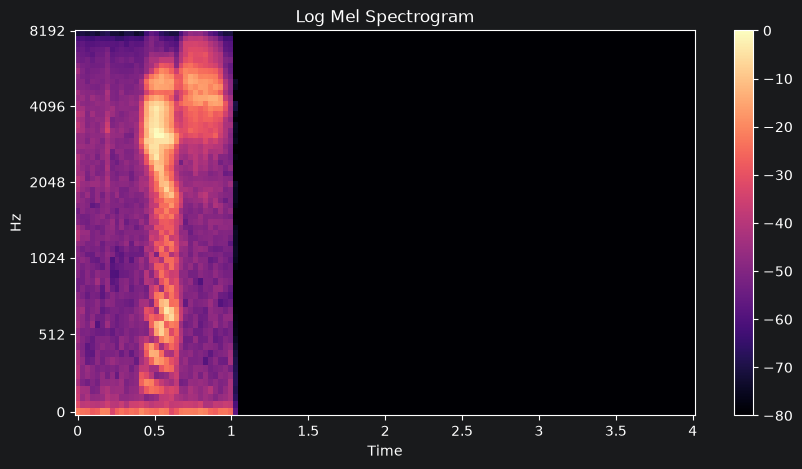

CNN Input Shape: (1, 64, 126)


In [40]:
#Log mel spectrogram
mel = preprocessor.extract_mel_spectrogram(processed_audio)
plt.figure(figsize=(10,5))
librosa.display.specshow(
    mel[0],sr=preprocessor.sr,
    hop_length=preprocessor.hop_length,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.title("Log Mel Spectrogram")
plt.show()
mel = preprocessor.process(sample_path)
print("CNN Input Shape:", mel.shape)

In [46]:
# Step 3
# Dataset and Dataset loader
#Class mapping
classes_lst
label_to_idx = {label: idx
                for idx, label in enumerate(classes_lst)
}

idx_to_label = { idx: label
    for label, idx in label_to_idx.items()
}
print(idx_to_label)

{0: 'backward', 1: 'bed', 2: 'bird', 3: 'cat', 4: 'dog', 5: 'eight', 6: 'follow', 7: 'forward', 8: 'wow', 9: 'yes'}


In [48]:
# Getting files from dataset
file_list = []
labels = []
for cls in classes_lst:
    folder = os.path.join(dataset_path, cls)
    for file in os.listdir(folder):
        if file.endswith(".wav"):
            file_list.append(
                os.path.join(folder, file))
            labels.append(label_to_idx[cls])
print("Total files:", len(file_list))

Total files: 22991


In [49]:
# Splitting into Train, test and validation set

train_files, temp_files, train_labels, temp_labels = train_test_split(
    file_list,
    labels,
    test_size=0.30,
    random_state=10,
    stratify=labels
)

val_files, test_files, val_labels, test_labels = train_test_split(temp_files,temp_labels,
    test_size=0.50,random_state=10,stratify=temp_labels
)
print(f'Train set:{len(train_files)} files')
print(f'Validation set:{len(val_files)} files')
print(f'Test set:{len(test_files)} files')

Train set:16093 files
Validation set:3449 files
Test set:3449 files


In [50]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, file_list, labels, preprocessor, augment=None):
        """
        file_list: list of audio file paths
        labels: list of integer labels
        preprocessor: AudioPreprocessor instance
        augment: optional augmentation (None for Part A)
        """
        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment
    def __len__(self):
        return len(self.file_list)
    def __getitem__(self, idx):
        """
        1. Preprocess audio -> log mel spectrogram
        2. Apply augmentation if provided (Part B only)
        3. Return (spectrogram_tensor, label)
        """
        path = self.file_list[idx]
        label = self.labels[idx]
        spec = self.preprocessor.process(path)
        spec = torch.tensor(
            spec, dtype=torch.float32)
        if self.augment is not None:
            spec = self.augment(spec)
        return spec, label

In [51]:
# Creating objects for dataset
train_dataset = AudioDataset(train_files,train_labels,preprocessor)

val_dataset = AudioDataset(val_files,val_labels,preprocessor)

test_dataset = AudioDataset(test_files,test_labels,preprocessor)

In [52]:
# Creating objects for data loader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)

test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

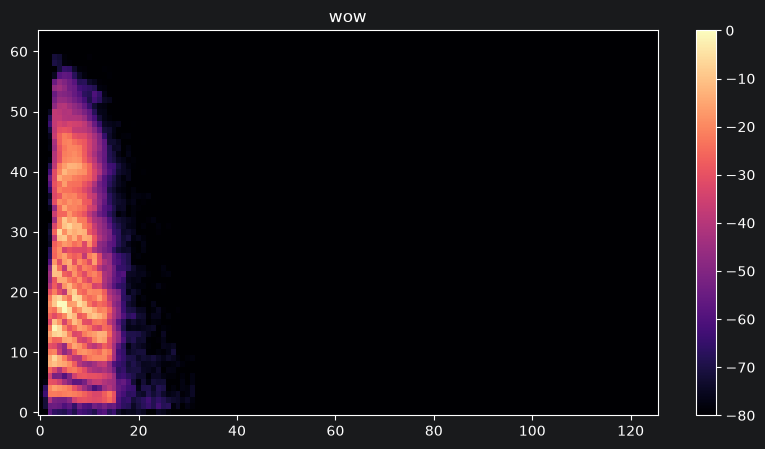

In [55]:
#Visualize training sample
sample, label = train_dataset[0]
plt.figure(figsize=(10,5))
plt.imshow(sample.squeeze(),origin="lower",aspect="auto",cmap="magma")
plt.title(idx_to_label[label])

plt.colorbar()

plt.show()

In [60]:
# Step 4
import torch.nn as nn
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super(AudioCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [57]:
num_classes = len(classes_lst)
model = AudioCNN(num_classes)
print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout

In [58]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),lr=0.001
)

In [59]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
model = model.to(device)

print(device)

cpu


In [61]:
#Step 5 : Training without arguments
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for spectrograms, labels in loader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(spectrograms)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [62]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for spectrograms, labels in loader:
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)
            outputs = model(spectrograms)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [65]:
NUM_EPOCHS = 5
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,train_loader,criterion,optimizer,device)
    val_loss, val_acc = validate(
        model,val_loader,criterion,device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "best_audio_model_cnn.pth"
        )
    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/5] Train Loss: 1.3357 Train Acc: 54.27% Val Loss: 1.2976 Val Acc: 54.51%
Epoch [2/5] Train Loss: 1.1672 Train Acc: 60.49% Val Loss: 1.0745 Val Acc: 60.77%
Epoch [3/5] Train Loss: 1.0388 Train Acc: 64.52% Val Loss: 0.9470 Val Acc: 69.35%
Epoch [4/5] Train Loss: 0.9561 Train Acc: 67.84% Val Loss: 0.8463 Val Acc: 72.77%
Epoch [5/5] Train Loss: 0.8824 Train Acc: 70.47% Val Loss: 0.8955 Val Acc: 69.53%


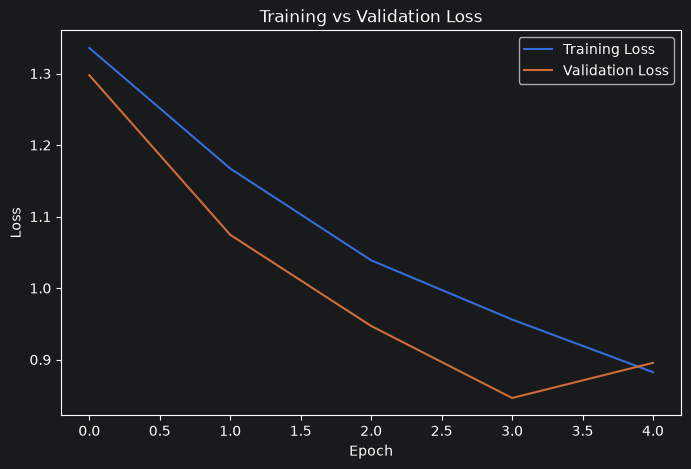

In [67]:
model.load_state_dict(torch.load("best_audio_model_cnn.pth"))
plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Training Loss")
plt.plot(val_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

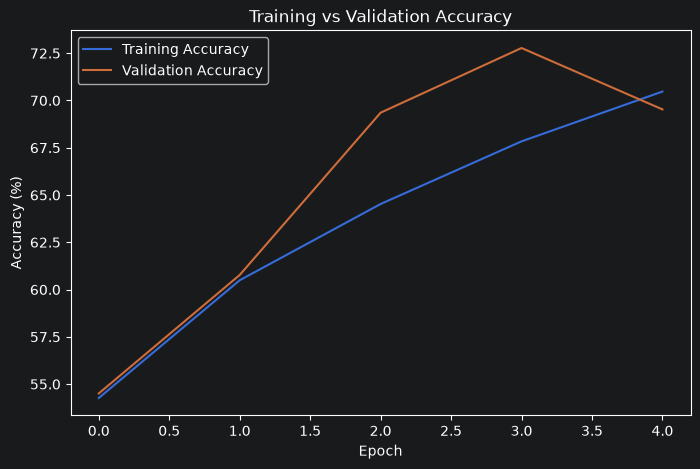

In [68]:
plt.figure(figsize=(8,5))
plt.plot(train_accs,label="Training Accuracy")
plt.plot(val_accs,label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [69]:
from sklearn.metrics import ( confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score)

import seaborn as sns

In [71]:
model.eval()
y_true = []
y_pred = []
correct_examples = []
incorrect_examples = []
with torch.no_grad():
    for spectrograms, labels in test_loader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)
        outputs = model(spectrograms)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        for i in range(len(labels)):
            if predicted[i] == labels[i]:
                if len(correct_examples) < 3:
                    correct_examples.append((spectrograms[i].cpu(),labels[i].cpu(),predicted[i].cpu()))
            else:
                if len(incorrect_examples) < 3:
                    incorrect_examples.append((spectrograms[i].cpu(), labels[i].cpu(),predicted[i].cpu()))

In [72]:
#printing metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true,y_pred,average="macro")
recall = recall_score(y_true,y_pred,average="macro")
f1 = f1_score(y_true,y_pred,average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7370
Precision : 0.7401
Recall : 0.6968
F1 Score : 0.7024


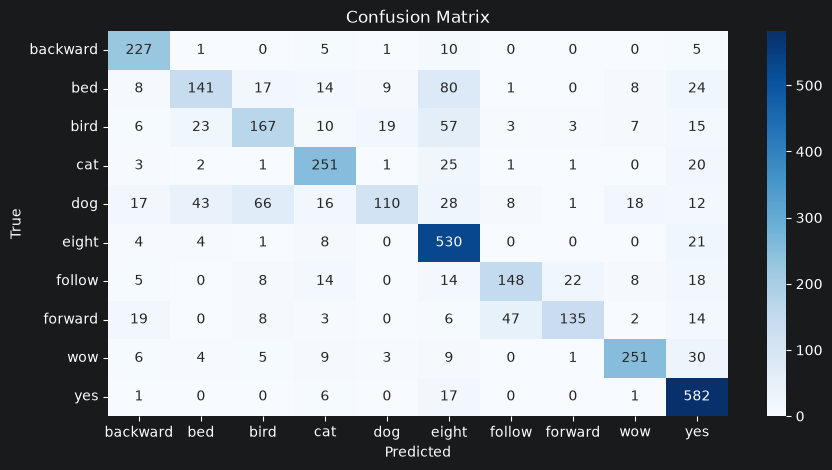

In [74]:
cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes_lst,
    yticklabels=classes_lst
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

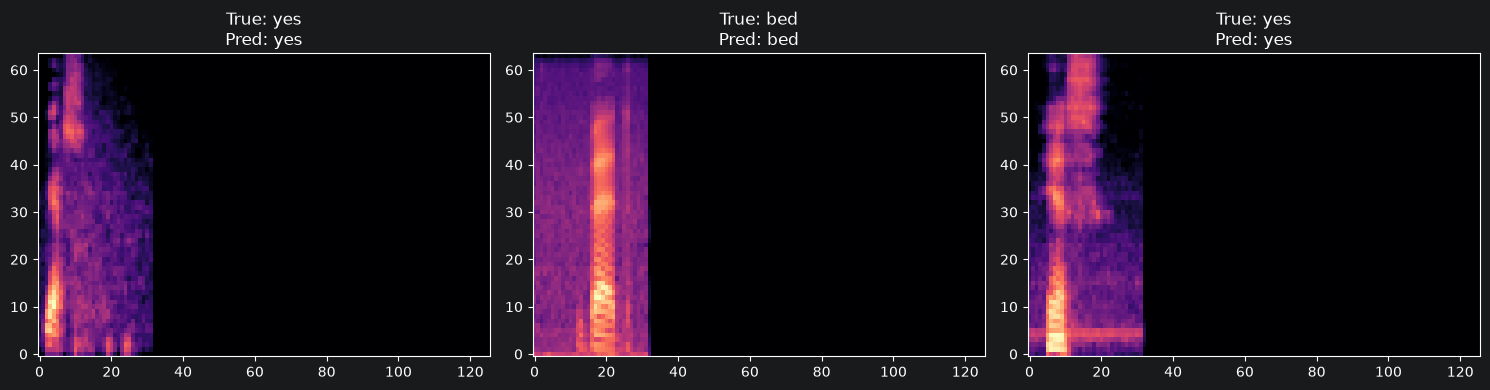

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, (spec, true_label, pred_label) in enumerate(correct_examples):
    axes[i].imshow(
        spec.squeeze(),
        origin="lower",
        aspect="auto",
        cmap="magma"
    )
    axes[i].set_title(
        f"True: {idx_to_label[int(true_label)]}\n"
        f"Pred: {idx_to_label[int(pred_label)]}"
    )
plt.tight_layout()
plt.show()

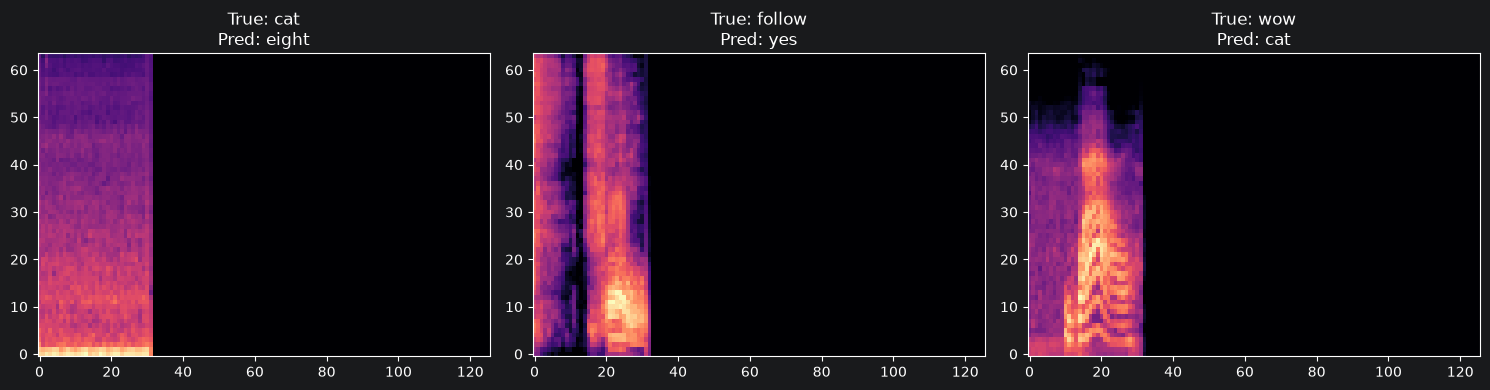

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, (spec, true_label, pred_label) in enumerate(incorrect_examples):
    axes[i].imshow(
        spec.squeeze(),
        origin="lower",
        aspect="auto",
        cmap="magma"
    )
    axes[i].set_title(
        f"True: {idx_to_label[int(true_label)]}\n"
        f"Pred: {idx_to_label[int(pred_label)]}"
    )
plt.tight_layout()
plt.show()

Part B: Classification with spec Arguments

In [80]:
class SpecAugment:
    def __init__(self,freq_mask_param=15,time_mask_param=35,num_freq_masks=2,num_time_masks=2):
        self.F = freq_mask_param
        self.T = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def freq_mask(self, spec): # Horizontal Mask
        _, n_mels, n_frames = spec.shape
        f = random.randint(0, self.F)
        if f == 0:
            return spec
        f0 = random.randint(0, max(0, n_mels - f))
        spec[:, f0:f0+f, :] = 0
        return spec

    def time_mask(self, spec): # Vertical mask
        _, n_mels, n_frames = spec.shape
        t = random.randint(0, self.T)
        if t == 0:
            return spec
        t0 = random.randint(0, max(0, n_frames - t))
        spec[:, :, t0:t0+t] = 0
        return spec

    def __call__(self, spec):
        spec = spec.clone()
        for _ in range(self.num_freq_masks):
            spec = self.freq_mask(spec)
        for _ in range(self.num_time_masks):
            spec = self.time_mask(spec)
        return spec

In [81]:
augment = SpecAugment()

In [82]:
sample_spec, label = train_dataset[0]

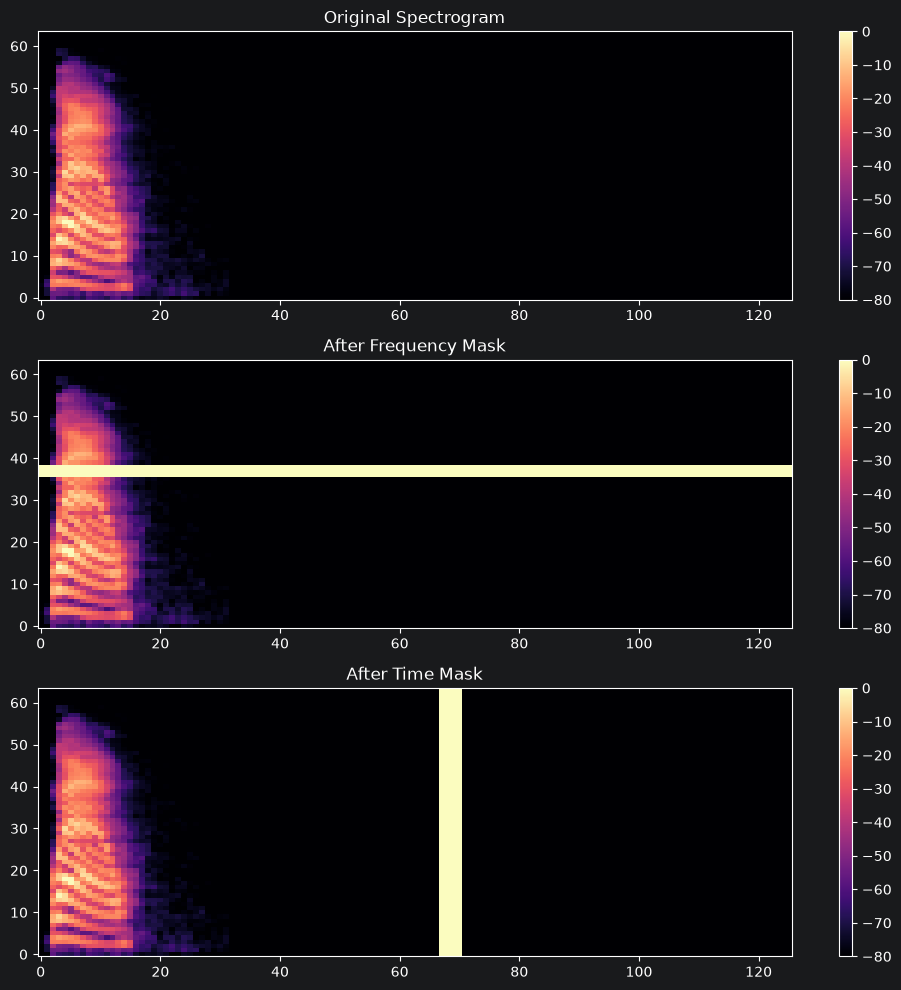

In [89]:
plt.figure(figsize=(10,10))
freq_aug = SpecAugment(num_freq_masks=1,num_time_masks=0)
freq_spec = freq_aug(sample_spec)
time_aug = SpecAugment(num_freq_masks=0,num_time_masks=1)
time_spec = time_aug(sample_spec)


plt.subplot(3,1,1)
plt.imshow(sample_spec.squeeze(),origin="lower",aspect="auto",cmap="magma")
plt.title("Original Spectrogram")
plt.colorbar()

plt.subplot(3,1,2)
plt.imshow(freq_spec.squeeze(),origin="lower",aspect="auto",cmap="magma")
plt.title("After Frequency Mask")
plt.colorbar()

plt.subplot(3,1,3)
plt.imshow(time_spec.squeeze(),origin="lower",aspect="auto",cmap="magma")
plt.title("After Time Mask")
plt.colorbar()


plt.tight_layout()
plt.show()

In [91]:
train_dataset_aug = AudioDataset(train_files,train_labels,preprocessor,augment=SpecAugment()
)

In [92]:
val_dataset_aug = AudioDataset(val_files,val_labels,preprocessor,augment=None)

test_dataset_aug = AudioDataset(test_files,test_labels,preprocessor,augment=None)

In [93]:
train_loader_aug = DataLoader(train_dataset_aug,batch_size=32,shuffle=True)

val_loader_aug = DataLoader(val_dataset_aug,batch_size=32,shuffle=False)

test_loader_aug = DataLoader(test_dataset_aug,batch_size=32,shuffle=False)

In [94]:
model_aug = AudioCNN(num_classes=len(classes_lst))

model_aug = model_aug.to(device)

In [95]:
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(),lr=0.001)

In [96]:
NUM_EPOCHS = 5
train_losses_aug = []
val_losses_aug = []
train_accs_aug = []
val_accs_aug = []
best_val_acc_aug = 0
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model_aug,train_loader_aug,
                                            criterion_aug,optimizer_aug,device)

    val_loss, val_acc = validate(model_aug,val_loader_aug,criterion_aug,device)

    train_losses_aug.append(train_loss)
    val_losses_aug.append(val_loss)

    train_accs_aug.append(train_acc)
    val_accs_aug.append(val_acc)

    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc
        torch.save(
            model_aug.state_dict(),
            "best_audio_cnn_specaugment.pth"
        )
    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1/5 | Train Loss: 2.2485 | Train Acc: 17.30% | Val Loss: 2.1965 | Val Acc: 23.49%
Epoch 2/5 | Train Loss: 2.2084 | Train Acc: 20.11% | Val Loss: 2.1402 | Val Acc: 25.14%
Epoch 3/5 | Train Loss: 2.1539 | Train Acc: 22.46% | Val Loss: 2.0685 | Val Acc: 27.20%
Epoch 4/5 | Train Loss: 2.0781 | Train Acc: 24.92% | Val Loss: 2.2308 | Val Acc: 19.40%
Epoch 5/5 | Train Loss: 1.9711 | Train Acc: 29.04% | Val Loss: 1.6331 | Val Acc: 47.72%


In [97]:
model_aug.load_state_dict(
    torch.load("best_audio_cnn_specaugment.pth")
)

<All keys matched successfully>

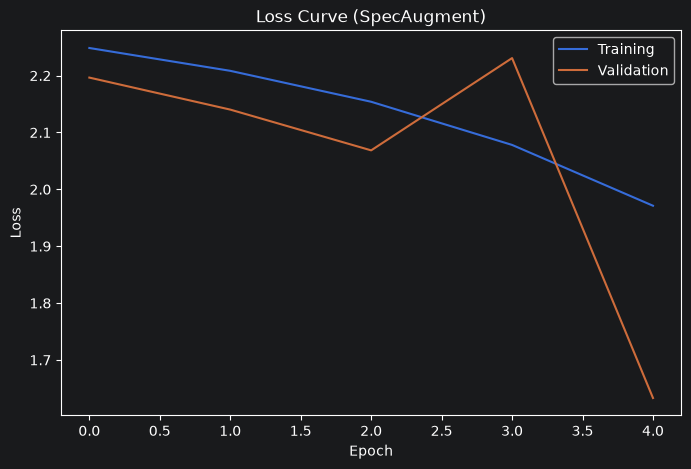

In [98]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_aug, label="Training")
plt.plot(val_losses_aug, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (SpecAugment)")
plt.legend()
plt.show()

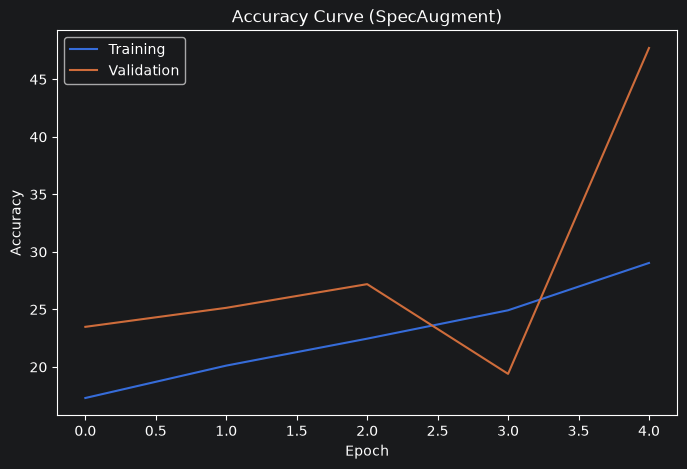

In [99]:
plt.figure(figsize=(8,5))
plt.plot(train_accs_aug, label="Training")
plt.plot(val_accs_aug, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve (SpecAugment)")
plt.legend()
plt.show()

In [100]:
model_aug.eval()

y_true_aug = []
y_pred_aug = []

correct_examples_aug = []
incorrect_examples_aug = []

with torch.no_grad():

    for spectrograms, labels in test_loader_aug:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model_aug(spectrograms)

        _, predicted = torch.max(outputs, 1)

        y_true_aug.extend(labels.cpu().numpy())
        y_pred_aug.extend(predicted.cpu().numpy())

        for i in range(len(labels)):
            if predicted[i] == labels[i]:
                if len(correct_examples_aug) < 3:
                    correct_examples_aug.append((spectrograms[i].cpu(),labels[i].cpu(),predicted[i].cpu()))
            else:
                if len(incorrect_examples_aug) < 3:
                    incorrect_examples_aug.append((spectrograms[i].cpu(),labels[i].cpu(),predicted[i].cpu()))

In [104]:
accuracy_aug = accuracy_score(y_true_aug, y_pred_aug)

precision_aug = precision_score(y_true_aug,y_pred_aug,average="macro")
recall_aug = recall_score(y_true_aug,y_pred_aug,average="macro")
f1_aug = f1_score(y_true_aug,y_pred_aug,average="macro")

print(f"Accuracy : {accuracy_aug:.4f}")
print(f"Precision: {precision_aug:.4f}")
print(f"Recall   : {recall_aug:.4f}")
print(f"F1 Score : {f1_aug:.4f}")

Accuracy : 0.4769
Precision: 0.4100
Recall   : 0.4088
F1 Score : 0.3944


D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [103]:
print(classification_report(y_true_aug,y_pred_aug,target_names=classes_lst))

              precision    recall  f1-score   support

    backward       0.57      0.56      0.57       249
         bed       0.00      0.00      0.00       302
        bird       0.47      0.41      0.44       310
         cat       0.42      0.31      0.36       305
         dog       0.33      0.31      0.32       319
       eight       0.64      0.71      0.67       568
      follow       0.31      0.29      0.30       237
     forward       0.51      0.18      0.26       234
         wow       0.36      0.46      0.40       318
         yes       0.49      0.87      0.63       607

    accuracy                           0.48      3449
   macro avg       0.41      0.41      0.39      3449
weighted avg       0.43      0.48      0.44      3449



D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

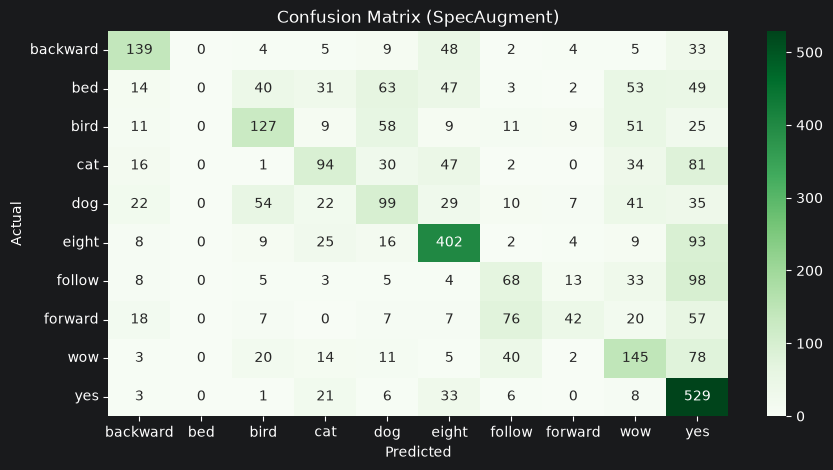

In [106]:
cm_aug = confusion_matrix(
    y_true_aug,
    y_pred_aug
)

plt.figure(figsize=(10,5))

sns.heatmap(cm_aug,annot=True,fmt="d",cmap="Greens",xticklabels=classes_lst,yticklabels=classes_lst)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SpecAugment)")
plt.show()

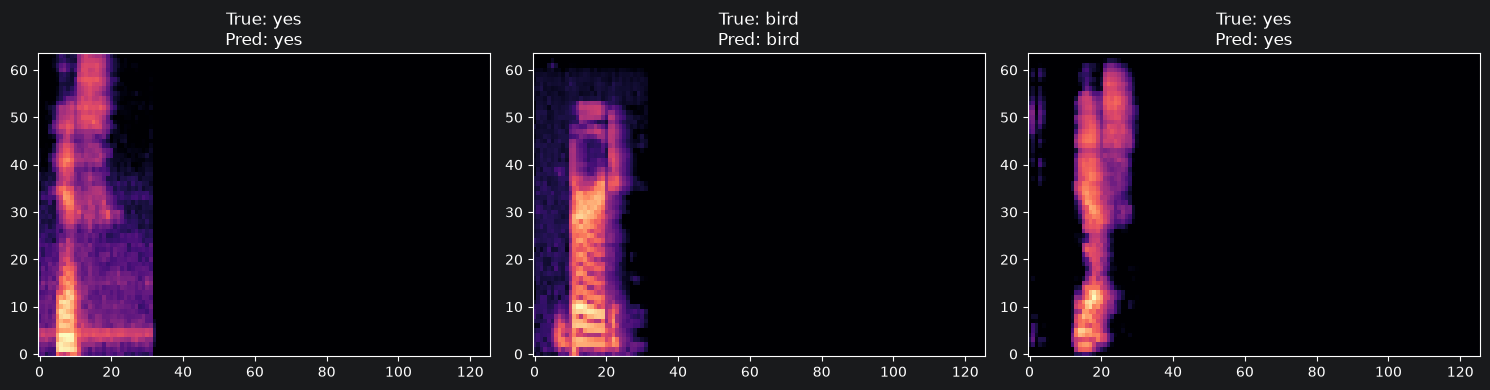

In [107]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

for i, (spec, true_label, pred_label) in enumerate(correct_examples_aug):
    axes[i].imshow(
        spec.squeeze(),
        origin="lower",
        aspect="auto",
        cmap="magma"
    )
    axes[i].set_title(
        f"True: {idx_to_label[int(true_label)]}\n"
        f"Pred: {idx_to_label[int(pred_label)]}"
    )
plt.tight_layout()
plt.show()

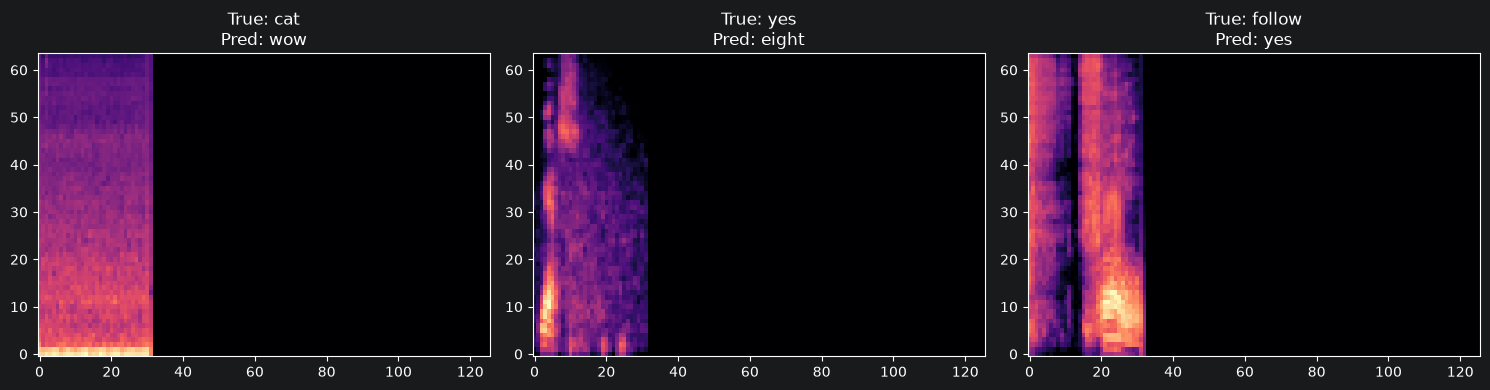

In [108]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

for i, (spec, true_label, pred_label) in enumerate(incorrect_examples_aug):

    axes[i].imshow(
        spec.squeeze(),
        origin="lower",
        aspect="auto",
        cmap="magma"
    )

    axes[i].set_title(
        f"True: {idx_to_label[int(true_label)]}\n"
        f"Pred: {idx_to_label[int(pred_label)]}"
    )

plt.tight_layout()

plt.show()

In [109]:
comparison = pd.DataFrame({
    "Metric":["Test Accuracy","Macro Precision","Macro Recall","Macro F1 Score"],

    "Without SpecAugment":[accuracy,precision,recall,f1],
    "With SpecAugment":[accuracy_aug,precision_aug,recall_aug,f1_aug ]
})

comparison

,Metric,Without SpecAugment,With SpecAugment
0,Test Accuracy,0.737025,0.476950
1,Macro Precision,0.740068,0.409989
2,Macro Recall,0.696764,0.408808
3,Macro F1 Score,0.702396,0.394433


In [110]:
gap_without = train_accs[-1] - val_accs[-1]
gap_with = train_accs_aug[-1] - val_accs_aug[-1]
print("Training - Validation Gap")
print(f"Without SpecAugment : {gap_without:.2f}%")
print(f"With SpecAugment    : {gap_with:.2f}%")

Training - Validation Gap
Without SpecAugment : 0.94%
With SpecAugment    : -18.69%


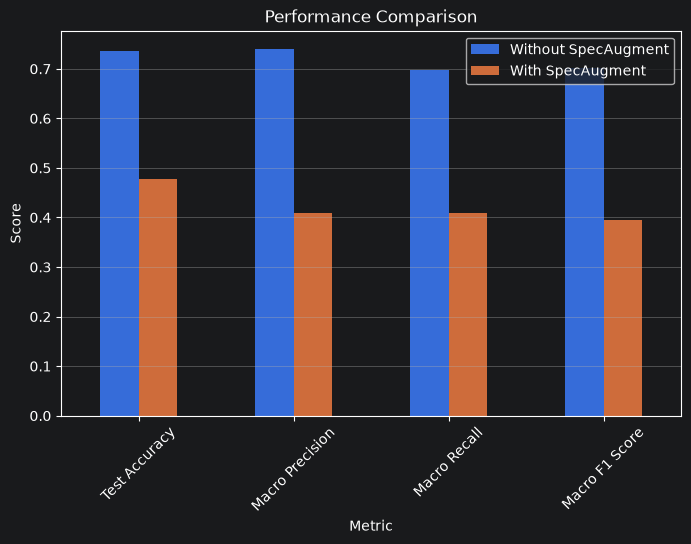

In [111]:
comparison_plot = comparison.set_index("Metric")
comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)
plt.ylabel("Score")
plt.title("Performance Comparison")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()